In [3]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
file_path = "metherology_dataset.csv"
df = pd.read_csv(file_path)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158112 entries, 0 to 158111
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   location              158112 non-null  object 
 1   time                  158112 non-null  object 
 2   temperature_2m        158112 non-null  float64
 3   relative_humidity_2m  158112 non-null  int64  
 4   dew_point_2m          158112 non-null  float64
 5   rain                  158112 non-null  float64
 6   cloud_cover           158112 non-null  int64  
 7   cloud_cover_low       158112 non-null  int64  
 8   cloud_cover_mid       158112 non-null  int64  
 9   cloud_cover_highh     158112 non-null  int64  
 10  wind_speed_10m        158112 non-null  float64
 11  wind_direction_10m    158112 non-null  int64  
 12  wind_gusts_10m        158112 non-null  float64
 13  wind_direction_100m   158112 non-null  int64  
 14  wind_speed_100m       158112 non-null  float64
 15  

In [7]:
# remover velores repetidos
df = df.drop_duplicates()

# Lista de colunas
cols_pretendidas = ['temperature_2m', 'dew_point_2m', 'cloud_cover', 'wind_speed_10m', 'pressure_msl']

cols_to_fix = [col for col in cols_pretendidas if col in df.columns]

# Verifica se existem nulos nessas colunas
null_counts = df[cols_to_fix].isnull().sum()

if null_counts.sum() > 0:
    # Preenche com a média
    df[cols_to_fix] = df[cols_to_fix].fillna(df[cols_to_fix].mean())

DataFrame columns after reloading and cleaning: Index(['location', 'time', 'temperature_2m', 'relative_humidity_2m',
       'dew_point_2m', 'rain', 'cloud_cover', 'cloud_cover_low',
       'cloud_cover_mid', 'cloud_cover_highh', 'wind_speed_10m',
       'wind_direction_10m', 'wind_gusts_10m', 'wind_direction_100m',
       'wind_speed_100m', 'pressure_msl', 'surface_pressure'],
      dtype='object')


/tmp/ipykernel_207/1669829821.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='location', y='temperature_2m', data=df, palette='viridis')


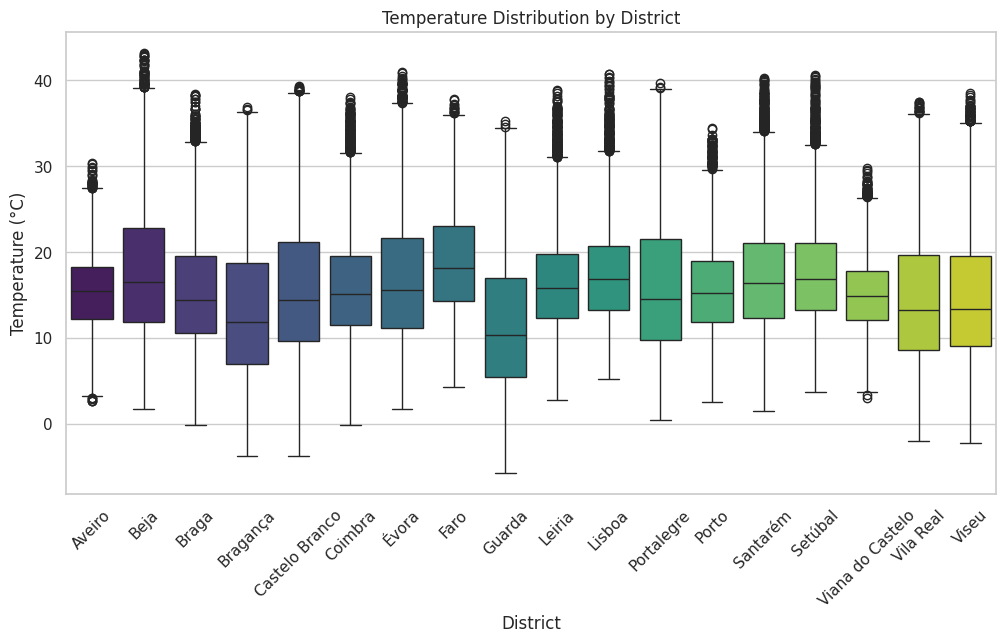

In [8]:
df.columns = df.columns.str.strip()

print("DataFrame columns after reloading and cleaning:", df.columns)

df['time'] = pd.to_datetime(df['time'])

sns.set_theme(style="whitegrid")

# Temperature Boxplot by District
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='temperature_2m', data=df, palette='viridis')
plt.title('Temperature Distribution by District')
plt.xticks(rotation=45)
plt.xlabel('District')
plt.ylabel('Temperature (°C)')
plt.show()

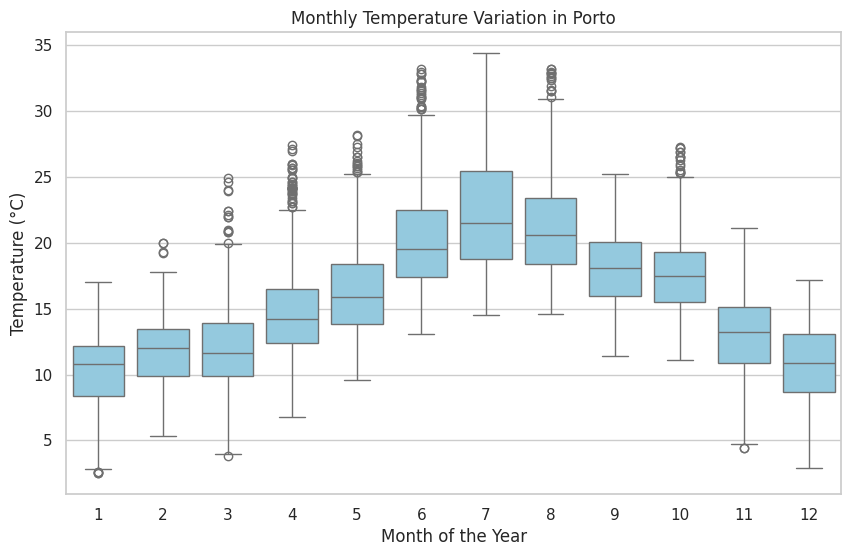

In [9]:
# Monthly Temperature Boxplot (Porto only)

df['month'] = df['time'].dt.month

# Filter data for Porto only
df_porto = df[df['location'] == 'Porto']

plt.figure(figsize=(10, 6))
sns.boxplot(x='month', y='temperature_2m', data=df_porto, color='skyblue')
plt.title('Monthly Temperature Variation in Porto')
plt.xlabel('Month of the Year')
plt.ylabel('Temperature (°C)')
plt.show()

In [10]:
import numpy as np
import pandas as pd
from pathlib import Path # Changed from PurePath to Path
from math import pi, sin, cos

# --- Start of fix: Reload and preprocess df ---
# Re-load the DataFrame to ensure all columns are present and consistent
file_path = "metherology_dataset.csv"  # Ensure this path is correct
df = pd.read_csv(file_path)

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# Ensure 'time' column is datetime type
df['time'] = pd.to_datetime(df['time'])
# --- End of fix ---

# For now adding just day_of_year and time_of_day
# In the future these should be encoded with sin and cos
# sin/cos(2pi(value/max(value)))
df['day_of_year'] = df['time'].dt.day_of_year
df['time_of_day'] = df['time'].dt.hour + df['time'].dt.minute / 60
# Our dataset has no minutes other than 0 (I think) but this handles them if they exist
# It also completely ignores seconds and the year
df = df.drop('time', axis=1)

# Cyclical encoding
# This maps hour and day to a trigonometric circle (it separates them in two variables)
df['day_sin'] = [sin(2*pi*(v / 365)) for v in df['day_of_year']]
df['day_cos'] = [cos(2*pi*(v / 365)) for v in df['day_of_year']]
df['hour_sin'] = [sin(2*pi*(v / 24)) for v in df['time_of_day']]
df['hour_cos'] = [cos(2*pi*(v / 24)) for v in df['time_of_day']]
# There is probably a much more efficient way to do this
df = df.drop(['day_of_year', 'time_of_day'], axis=1)

print(df[['day_sin', 'day_cos', 'hour_sin', 'hour_cos']].describe())

# Saving processed file
save_name = 'meth_data_proc.csv'
save_path = Path('..', 'data', save_name) # Constructed with Path

# Create the parent directory if it doesn't exist
save_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(save_path, index=False)

             day_sin        day_cos      hour_sin      hour_cos
count  158112.000000  158112.000000  1.581120e+05  1.581120e+05
mean        0.002437       0.001235  1.385251e-17 -3.936112e-17
std         0.707676       0.706537  7.071090e-01  7.071090e-01
min        -0.999991      -0.999963 -1.000000e+00 -1.000000e+00
25%        -0.705584      -0.708627 -7.071068e-01 -7.071068e-01
50%         0.004303       0.004304  6.123234e-17 -6.123234e-17
75%         0.711657       0.702527  7.071068e-01  7.071068e-01
max         0.999991       1.000000  1.000000e+00  1.000000e+00
